# Community

A set of nodes more densely connected among themselves than to the rest of the network. Coscia: _if two nodes are in the same community, they are more likely to be connected_. A __partition__ assigns every node to exactly one community.

## Edge betweenness · Girvan–Newman

__Edge betweenness__ is the number of shortest paths that run along a link (shared equally when a pair has several). __Girvan–Newman__ (2002): remove the link with the highest edge betweenness, recompute every value, repeat; the network falls apart into groups, biggest cuts first. Slow: $O(m^2 n)$.

## Dendrogram

The tree of groups a hierarchical method produces: one group at the root, single nodes (or links) at the leaves, one level per split or merge. Girvan–Newman builds it top-down (splitting), Newman's greedy method bottom-up (merging). Cut it at the level with the best score.

## Modularity Q

$Q = \frac{1}{2m} \sum_{ij} \left( A_{ij} - \frac{k_i k_j}{2m} \right) \delta(c_i, c_j)$: the fraction of links inside communities minus what the degree-preserving null expects. Per community: $Q = \sum_c [\ell_c/m - (d_c/2m)^2]$ with $\ell_c$ the links inside $c$ and $d_c$ its members' summed degree. One community: $Q = 0$. Random assignment: $Q \approx 0$. It scores _how grouped_, not _how right_. Newman & Girvan (2004) introduced it to pick the level of a dendrogram.

## Greedy modularity (Newman 2004)

Start with every node alone; repeatedly merge the pair of communities whose merge raises $Q$ most; keep the level with the highest $Q$. Fast, but a merge is never undone.

## Louvain

__Phase 1__ move nodes: every node starts alone; visit nodes in turn and move each to the neighboring community that raises $Q$ most, until a sweep moves nobody. __Phase 2__ aggregate: each community becomes a super-node, crossing links become weighted links, repeat. Greedy, fast, and seed-dependent: the visiting order changes the result.

## Modularity of a random network

Not zero. A degree-preserving shuffle of the philosophers scores $Q \approx 0.23$ (Marvel: $0.25$), and the sparser the network, the higher: a random network with average degree 2 reaches $Q \approx 0.8$. Report a modularity against its null, as a difference or a $z$-score.

## Stability · NMI

Different seeds give different partitions with nearly equal $Q$ (philosophers: 8–10 communities, NMI 0.65–0.83 between runs; Marvel: 0.59). __Normalized mutual information__ scores the agreement of two labelings: 1 = identical, 0 = independent. Use it against ground truth when you have it and between runs when you do not.

## k-clique community (clique percolation)

Palla et al. 2005: two $k$-cliques are adjacent if they share $k-1$ nodes; a community is everything reachable by rolling from one to an adjacent one. Communities overlap, and nodes in no $k$-clique are in none. Small $k$ percolates into one giant; large $k$ leaves most nodes out. Software: `CFinder`.

## Overlapping communities · link communities

Real nodes belong to several groups; a partition must get all but one wrong. __Link communities__ (Ahn, Bagrow & Lehmann 2010): cluster the _links_ by the similarity of their endpoints' neighborhoods; each node inherits every community its links are in. __Partition density__ $D$ picks the cut: each link community's density between a tree and a clique, averaged by its number of links. __The overlap paradox__: overlap nodes sit between groups, so density-based node methods rank them as the least community-like.

## Weight · strength

A weight $w_{ij}$ on a link; __strength__ $s_i = \sum_j w_{ij}$ replaces degree. Weighted distance: link length $1/w_{ij}$, shortest paths by Dijkstra. Weighted modularity: $w_{ij}$ for $A_{ij}$, strengths for degrees, total weight for $m$; not comparable to the unweighted value.

## Global threshold

Keep $w \ge \theta$. Keeps hubs' minor ties and drops small nodes' strongest ones; the backbone becomes the hubs alone.

## Disparity filter

Per-node null: node $i$'s strength spread uniformly over its $k_i$ links. With $p_{ij} = w_{ij}/s_i$, a link is significant for $i$ when $(1 - p_{ij})^{k_i - 1} < \alpha$; keep it if significant at either end. Keeps every node's _own_ important ties. $\alpha$ is a choice you report.

## The five drawing rules

1. Backbone first, if the network needs filtering (a method you can defend, a parameter, say what was removed)
2. Layout of the backbone, not the full network
3. Color by community when the structure is real, detected on the full data, not on the backbone; group or label the groups, not color alone
4. Size by degree, strength or centrality
5. Label the important nodes. Document the steps in your report.

# 1. Communities  

Cliques are a kind of super-community; otherwise _community_ covers groups of nodes. We look for communities for three reasons:
- **Summary**: level of individual nodes too low, whole network too high level
- **Meaning**: Community helps you understand what is going on; it can be different schools in plilosophy
- **Visualization**: coloring by community can help make us understand networks



# 2. Cutting the Bridsges; _edge betweenness_

Just like _node betweenness_, the number of shortest paths through a node, we have the similar definition for _edge betweenness_.

Girvan-Newman thought that communities are linked by edges with _high betweenness_! Because paths between groups carry most/all the groups traffic! The idea is the following (the **Girvan-Newman** algorithm (_nx_: `girvan_newman`))
1. Compute _edge betweenness_ of every link
2. Remove the link with highest value
3. Recompute all values (removal re-routes traffic)
4. Repeat

Possible to record as groups split, known as a __dendogram__. It is, however, _slow_: $O(m^2n)$

## 4.1) Cutting by hand

Draw this network: nodes A–G, links A–B, A–C, B–C, C–D, D–E, D–F, E–F, F–G. ($m=8$) Exercises 4.3 and 4.10 use it again.

1) Compute the edge betweenness of every link by counting. There are 21 pairs of nodes; for each pair find the shortest path and add 1 to every link on it (this network has no ties, so no pair has two shortest paths). Some links are quick: C–D carries every path between {A, B, C} and {D, E, F, G}. Which link does Girvan–Newman remove first?
    - We remove edge C-D with betweenness 15 
    ![image.png](4.1.1.png)
2) Remove it and recompute. Which values changed? Explain in one sentence why F–G's value is now half what it was.
    - Almost all values changed, except for two links; F-G's betweenness value halved because we cut off access to the left side {A, B, C}, which when counting both ways is 6 paths! (12/2)
    ![image.png](4.1.2.png)
3) Remove the next link. Draw the first two levels of the dendrogram: which groups appear at level 1, and which at level 2?
    - G becomes isolated. Dendogram would look like the following; 
        - Level 1 split: {ABC}, {DEFG}
        - Level 2 split: {ABC}, {DEF}, {G}
4) Why does Girvan–Newman recompute after every removal instead of computing edge betweenness once and removing the links in that order? Point to the moment in the explorable where it matters.
    - We do it because paths change; D-F is actually '16' in the first figure, so it would erroneously be removed after the 1st level.


# 3. A Dendogram isn't really a community: introducing _modularity_

The Girvan-Newman algorithm just splits into parts, but doesn't say much about community itself. They later specified a way to quantify community, known as __modularity__.

__Modularity__ scores a proposed split; high scores equal good splitting. As always _compared to what_? Use null-model with degree preserving, and compare to that; the expected number of links is $k_ik_j/2m$. If you subtract it from the actual number of links, you get the _modularity_:
$$ Q = \frac{1}{2m} \sum_{ij} \left( A_{ij} - \frac{k_ik_j}{2m} \right)\delta(c_i,c_j), $$
where $\delta(c_i,c_j)=1$ exactly when node $i$ and node $j$ is in the same community. $m$ and $d_c$, and others, is from the un-fragmented network, so before removing edges, even when looking at the network after removing edges. As such, it is "_fraction of links in community, minus that you would expect from chance, given the degrees_. For hand computation, it might be easier to do:
$$ Q = \sum_c\left[ \frac{\ell_c}{m} - \left( \frac{d_c}{2m} \right)^2 \right], $$
where $\ell_c$ is number of links in community $c$, and $d_c$ the sum of degree of its members.

From an explorable on the website, we see that the highest modularity doesn't come from the "right split". A better split happens at 4 groups, despite it not being the right split for that graph; this is because it only quantifies _how grouped a partition is_.

### 4.2
No notebook, no chatbot. Think, then write.
1) Define a community in one sentence, then explain why "the nodes that are all connected to each other" is not a good definition (what would it say about the philosophers?).
    - A community is a collection of nodes, where distances between each other are very short, and many share paths to other communities through a select few. A clique is a good, tight community, but it fails to capture the more relaxed communities, where you have center figures and other such nodes.
2) Why does modularity subtract $k_i​k_j​/2m$? What would go wrong if you scored a partition by the fraction of links inside communities alone?
    - You would max out when all nodes where in 2-cliques, as it favors fragmentation.
3) In the karate club, Louvain's four groups score higher than the real two factions. Does that mean the four groups are "more real"? What does it mean?
    - No, it doesn't make it more real, but it does mean that the split that gives 4 groups gives more grouped partition.
4) A friend reports "modularity 0.35, so the network has community structure." List the two questions you would ask before believing it.
    - What ranges of modularity does the network allow for?

### 4.2) Modularity By Hand

Use the network from exercise 4.1: nodes A–G, links A–B, A–C, B–C, C–D, D–E, D–F, E–F, F–G ($m=8$).

1) Compute $Q$ for the partition $\{A, B, C\}$ · $\{D, E, F, G\}$ using the per-community formula: for each group, count the links inside it and add up its members' degrees.
    - $$ Q = \left( (3/8 - (7/16)^2) + (4/8 - (9/16)^2) \right) = 0.36 $$
2) Compute $Q$ for the partition \{A, B, C, D\} · \{E, F, G\}. Which of the two is better, and by how much? Explain in one sentence, from the network drawing, why.
    - $$ Q = \left( (4/8 - (8/16)^2) + (2/8 - (4/16)^2) \right) = 0.21 $$
    So this scores lower, but I also think it is less right; D was connected to both E and F, but we cut off both of them in favor of keeping them in ABC..
3) Compute $Q$ for level 2 of your dendrogram from exercise 4.1. Which level of the dendrogram would Newman and Girvan cut at?
    - $$ Q = \left( (3/8 - (7/16)^2) + (3/8 - (8/16)^2) + (0/8 - (0/16)^2) \right) = 0.309 $$
    For this purpose, we would keep the split at level 1, from the modularity criterion.
4) Compute $Q$ for "everything in one community." Then argue, without computing, whether any partition of this network can score below that.
    - When we are at the full network we have $Q = 0$. I would expect leaving $G$ out would worsen Q.
5) Node G has degree 1. Show that moving G into the same community as F always raises QQ. (This is the reason community detection sticks leaves to their only neighbor.)
    Amounts to showing that
    $$ \ell/m - (d_c/2m)^2 > (\ell - 1)/m - ((d_c - 1) / 2m)^2$$
    I would think it amounts to showing that $4\ell - d_c^2 > (4\ell - 4)$

# Optimizing Modularity - Greedy Merging to Louvain

Finding the highest Q without dendograms is a very tough optimization task.

> "the number of ways to partition 1,374 nodes is a number with 2,804 digits, and finding the maximum exactly is NP-hard"

Instead, run Girvan-Newman _backwards_; every node is a leaf, merge those who raise Q the most. Repeat until one big community, and keep the split with the highest Q along the way. It is a _greedy_ algorithm, so early choise of merges are locked in.

Louvrain is a perhaps simpler and better version, which allows changes of earlier merges.
- __Phase 1: move nodes__. Every node in its own community; visit nodes 1 by 1; for each node, try to move into community with one of its neighbours, compute change to Q, and makes the best move if Q raises; otherwise leave it standing. Sweep all nodes, until no changes are made.
- __Phase 2: aggregate__. Collapse each community into a single super-node. Links between communities become one _weighted_ link, based on how many links crossed. Add weighed self-loop equal to number of links inside the community.

Repeat until phase 1 moves nothing.

You can run this on null-models as well, to compare the Q we would get, to see if the communities are significant compared to those null models or random networks even. A random network may also get A Q > 0!

__Stability__: running with different seeds (phase 1 nodes visited in different order), we get different solutions. To quantify how two partitions agree about splits, we introduce __normalized mutual information (NMI)__:
$$ I = \sum_{x,y} \frac{n_{xy}}{n} \log \frac{n n_{xy}}{n_xn_y},\quad\quad H_x = -\sum_x \frac{n_x}{n}\log\frac{n_x}{n}, $$
$$ \text{NMI} = 2I / (H_1 + H_2), $$
where $n_x, n_y$ are nodes in community $x$ and $y$, $n_{xy}$ numbers in both communities.

For code, we can use `sklearn.metrics.normalized_mutual_info_score(labels_a, labels_b)`

Because modularity can vary so much from run to run, don't view it as _ground truths_! However, if you _do have_ ground truth labels, you can use NMI as a score, to see how good your partition is against the real one with NMI.


In [ ]:
import networkx as nx
import numpy as np
import pandas as pd
from sklearn.metrics import normalized_mutual_info_score

nodes = pd.read_csv("week4_philosophers_nodes.tsv", sep="\t", comment="#", quoting=3)
edges = pd.read_csv("week4_philosophers_edges.tsv", sep="\t", comment="#")

G = nx.Graph()
G.add_nodes_from(nodes.node_id)
for s, t, w in edges.itertuples(index=False):
    if G.has_edge(s, t):
        G[s][t]["weight"] += w
    else:
        G.add_edge(s, t, weight=w)
giant = G.subgraph(max(nx.connected_components(G), key=len)).copy()
# G: 1444 nodes, 9140 links; giant: 1374 nodes, 9139 links

In [7]:
communities = nx.community.louvain_communities(giant)
len(communities), nx.community.modularity(giant, communities)
for community in communities:
    # Get the community graph from giant
    community_graph = giant.subgraph(community)

    # Compare community by "era" vs partition using NMI (sklearn.metrics.normalized_mutual_info_score(labels_a, labels_b))
    print(f"{normalized_mutual_info_score(
        [nodes[nodes.node_id == node].era.values[0] for node in community_graph.nodes()],
        [i for i, _ in enumerate(community_graph.nodes())]
    ):.2f}", end="; ")

    # Now versus subfields column (use "none" for the empty ones)
    print(f"{normalized_mutual_info_score(
        [nodes[nodes.node_id == node].subfields.values[0] if nodes[nodes.node_id == node].subfields.values[0] != "" else "none" for node in community_graph.nodes()],
        [i for i, _ in enumerate(community_graph.nodes())]
    ):.2f}", end="; ")

    # Print 5 highest degree nodes' names in the community graph
    print([nodes[nodes.node_id == node].name.values[0] for node, _ in sorted(community_graph.degree(), key=lambda x: x[1], reverse=True)[:5]])
    

0.39; 0.32; ['John Locke', 'René Descartes', 'Gottfried Wilhelm Leibniz', 'Isaac Newton', 'David Hume']
0.07; 0.40; ['Bertrand Russell', 'William James', 'Henri Bergson', 'Albert Einstein', 'Charles Sanders Peirce']
0.47; 0.27; ['The Buddha', 'Madhvacharya', 'Adi Shankara', 'Nagarjuna', 'Pāṇini']
0.22; 0.36; ['Immanuel Kant', 'Georg Wilhelm Friedrich Hegel', 'Friedrich Nietzsche', 'Friedrich Wilhelm Joseph Schelling', 'Karl Marx']
0.36; 0.34; ['Plato', 'Aristotle', 'Diogenes Laertius', 'Plutarch', 'Cicero']
0.34; 0.26; ['Thomas Aquinas', 'Augustine of Hippo', 'Avicenna', 'Averroes', 'Bonaventure']
0.55; 0.28; ['Zhu Xi', 'Mencius', 'Confucius', 'Zichan', 'Xunzi (philosopher)']


In [21]:
nodes = list(giant.nodes())

communities_g = nx.community.greedy_modularity_communities(giant)
map_greedy = {node: i for i, c in enumerate(communities_g) for node in c}
labels_greedy = [map_greedy[n] for n in nodes]

for i in range(5):

    communities = nx.community.louvain_communities(giant, seed=i)
    print(f"Louvain: {len(communities)}, {nx.community.modularity(giant, communities):.3f}", end="; ")

    map_ = {node: i for i, c in enumerate(communities) for node in c}
    label_ = [map_[n] for n in nodes]

    print(f"Greedy: {len(communities_g)}, {nx.community.modularity(giant, communities_g):.3f}", end="; ")

    #NMI between this greedy and louvrain
    print (f"NMI: {normalized_mutual_info_score(labels_greedy, label_):.3f}")

    

Louvain: 9, 0.546; Greedy: 15, 0.446; NMI: 0.468
Louvain: 7, 0.552; Greedy: 15, 0.446; NMI: 0.477
Louvain: 8, 0.554; Greedy: 15, 0.446; NMI: 0.509
Louvain: 9, 0.557; Greedy: 15, 0.446; NMI: 0.469
Louvain: 9, 0.564; Greedy: 15, 0.446; NMI: 0.475


### 4.6)

1) 🧠 Louvain has two phases. Say what each does in one or two sentences, and say what makes the result depend on the seed. Then: two Louvain runs on the same network give $Q=0.505$ and $Q=0.506$. Can you conclude they found nearly the same communities?
    - Phase 1: cycle nodes connecting to a neighbour if it _increases_ Q!
    - Phase 2: combine nodes that are connected to a supre node!
    - And no, they may have found very different partitions due to randomness, but both yielded a very similar modularity. We would NMI to check if they are mutually similar in information.
2) 🧠 Why is the modularity of a random network greater than zero? Which null should you compare a modularity against, and why is it the degree-preserving one rather than $G(n,m)$?
    - Even random networks can have, by chance, small communities that connect to each other. We want to use a degree-preserving null, as the degree of the community, as well as $m$ is part of the formula for modularity, and we want to preserve that, but observe how it changes with random links.

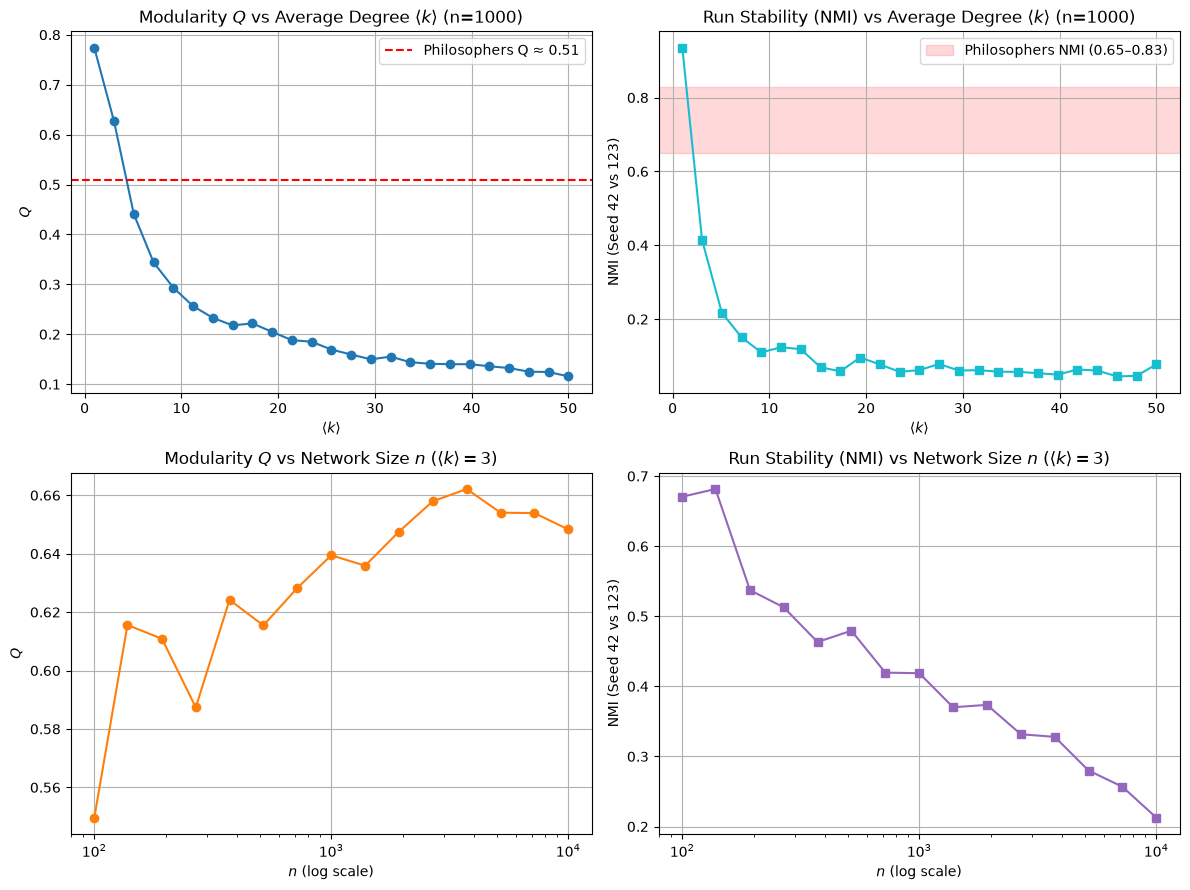

Random network matching Q ≈ 0.51:
  <k>: 5.08
  Q:   0.441
  NMI: 0.218 (Philosophers: 0.65 - 0.83)


In [23]:
import matplotlib.pyplot as plt


### 3)
def evaluate_graph(G, take_giant=True):
    """Run Louvain with two seeds, returning modularity and cross-run NMI."""
    if take_giant:
        if len(G) == 0:
            return 0.0, 0.0
        largest_cc = max(nx.connected_components(G), key=len)
        G = G.subgraph(largest_cc).copy()

    node_list = list(G.nodes())
    if len(node_list) <= 1:
        return 0.0, 1.0

    # Run 1
    comm1 = nx.community.louvain_communities(G, seed=42)
    q1 = nx.community.modularity(G, comm1)
    map1 = {node: cid for cid, c in enumerate(comm1) for node in c}
    labels1 = [map1[n] for n in node_list]

    # Run 2
    comm2 = nx.community.louvain_communities(G, seed=123)
    map2 = {node: cid for cid, c in enumerate(comm2) for node in c}
    labels2 = [map2[n] for n in node_list]

    nmi = normalized_mutual_info_score(labels1, labels2)
    return q1, nmi


# ---------------------------------------------------------
# Experiment 1: Fix n = 1000, vary average degree <k> from 1 to 50
# ---------------------------------------------------------
n_fixed = 1000
k_vals = np.linspace(1, 50, 25)
q_vs_k = []
nmi_vs_k = []

for k in k_vals:
    p = k / (n_fixed - 1)
    G = nx.erdos_renyi_graph(n_fixed, p, seed=42)
    q, nmi = evaluate_graph(G, take_giant=True)
    q_vs_k.append(q)
    nmi_vs_k.append(nmi)

# ---------------------------------------------------------
# Experiment 2: Fix <k> = 3, vary n from 100 to 10,000 (log scale)
# ---------------------------------------------------------
k_fixed = 3.0
n_vals = np.logspace(2, 4, 15, dtype=int)
q_vs_n = []
nmi_vs_n = []

for n in n_vals:
    p = k_fixed / (n - 1)
    G = nx.erdos_renyi_graph(n, p, seed=42)
    q, nmi = evaluate_graph(G, take_giant=True)
    q_vs_n.append(q)
    nmi_vs_n.append(nmi)

# ---------------------------------------------------------
# Plotting
# ---------------------------------------------------------
fig, axes = plt.subplots(2, 2, figsize=(12, 9))

# Q vs <k>
axes[0, 0].plot(k_vals, q_vs_k, "o-", color="tab:blue")
axes[0, 0].axhline(
    0.51, color="red", linestyle="--", label="Philosophers Q ≈ 0.51"
)
axes[0, 0].set_title(r"Modularity $Q$ vs Average Degree $\langle k \rangle$ (n=1000)")
axes[0, 0].set_xlabel(r"$\langle k \rangle$")
axes[0, 0].set_ylabel(r"$Q$")
axes[0, 0].grid(True)
axes[0, 0].legend()

# NMI vs <k>
axes[0, 1].plot(k_vals, nmi_vs_k, "s-", color="tab:cyan")
axes[0, 1].axhspan(
    0.65, 0.83, color="red", alpha=0.15, label="Philosophers NMI (0.65–0.83)"
)
axes[0, 1].set_title(
    r"Run Stability (NMI) vs Average Degree $\langle k \rangle$ (n=1000)"
)
axes[0, 1].set_xlabel(r"$\langle k \rangle$")
axes[0, 1].set_ylabel("NMI (Seed 42 vs 123)")
axes[0, 1].grid(True)
axes[0, 1].legend()

# Q vs n
axes[1, 0].plot(n_vals, q_vs_n, "o-", color="tab:orange")
axes[1, 0].set_xscale("log")
axes[1, 0].set_title(r"Modularity $Q$ vs Network Size $n$ ($\langle k \rangle=3$)")
axes[1, 0].set_xlabel(r"$n$ (log scale)")
axes[1, 0].set_ylabel(r"$Q$")
axes[1, 0].grid(True)

# NMI vs n
axes[1, 1].plot(n_vals, nmi_vs_n, "s-", color="tab:purple")
axes[1, 1].set_xscale("log")
axes[1, 1].set_title(
    r"Run Stability (NMI) vs Network Size $n$ ($\langle k \rangle=3$)"
)
axes[1, 1].set_xlabel(r"$n$ (log scale)")
axes[1, 1].set_ylabel("NMI (Seed 42 vs 123)")
axes[1, 1].grid(True)

plt.tight_layout()
plt.show()

# ---------------------------------------------------------
# Direct Comparison with Philosophers
# ---------------------------------------------------------
idx_match = int(np.argmin(np.abs(np.array(q_vs_k) - 0.51)))
matched_k = k_vals[idx_match]
matched_q = q_vs_k[idx_match]
matched_nmi = nmi_vs_k[idx_match]

print("Random network matching Q ≈ 0.51:")
print(f"  <k>: {matched_k:.2f}")
print(f"  Q:   {matched_q:.3f}")
print(f"  NMI: {matched_nmi:.3f} (Philosophers: 0.65 - 0.83)")

# Overlap 1) _k_-clique

Modularity is not the only quantity for finding community, we already saw cliques. Also, some nodes are in more than 1 community (in the real life).

This one explores overlapping communities through cliques; based on clique adjacency. Two $k$-cliques are adjacent if they share $k-1$ nodes. For $k=3$ it amounts to sharing a side in the triangles formed.

### 4.7) Cliques on paper

Draw two triangles, {A, B, C} and {C, D, E}, sharing the node C, plus one extra link A–F.

1) Any partition of the nodes puts C in one triangle. Compute Q for {A, B, C} · {D, E} · {F} and for {A, B} · {C, D, E} · {F}. Which scores higher? Whichever wins, what does each partition get wrong about C?
    - First one scores: 0.07
    - Second one scores: 0.11
    - They get it wrong that C belongs to both!
2) List every 3-clique. With $k=3$, which of them are adjacent, and what are the k-clique communities? Name the node that is in two communities, the node that is in none, and the link that belongs to no community.
    - First clique is ABC, next is CDE; None are adjacent, C is in both communities, F is in none, and FA is a link that belongs to no community.
3) Add the link B–D. List the 3-cliques again and find the $k=3$ communities. What happened, and why is this percolation in miniature? What does $k=4$ give?
    - 3 cliques are ABC, BCD, CDE; communities are then {ABC, BCD} and {BCD, CDE}. No 4-cliques.
4) On the philosophers, $k=3$ puts 1,155 philosophers in one community and $k=6$ leaves 78% of them out. Explain each in one sentence.
    - Many small triangles can form among philisophers pages on wikipedia, and all it requires it that each philisopher shares two friends with another small triangle of philosophers. Therefore, many will be in one large community; The requirements increase dramatically for larger values of $k$, as you need need to have distinc $k$-cliques, and they must share $k-1$ nodes between them to be considered part of the same community.

# Overlap 2) link communities

Instead lets look at links; we are looking for a kind of Jaccard style scoring. Two links share a node, $i-k$,$j-k$, are similar if the neighbourhoods of $i$ and $j$ overlap.

Cluster links by similarity, and each cluster of links is a __link community__. Similar to modularity for nodes, there is __partition density__:
$$ D = \frac{2}{M} \sum_c m_c \frac{m_c - (n_c - 1)}{(n_c - 2)(n_c - 1)} $$

# 7) Weighs: strong ties and weak links

Links can have __weights__. In __weighted__ networks, some things changes:
1) Nodes have degree _and_ __strength__: $s_i = \sum_j w_{ij}$. Strength and degree.
2) A weight between pages says a lot (wikipedia pages, how many mentions) more than a single link can
3) _paths are different in weighted networks_; need Dijkstra's; when using _strength_, then the length of a link is proportional to the inverse of the strength: $1/w_{ij}$.

### 4.10) Weights by hand
Take the network from exercise 4.1 and give the links weights: A–B 3, A–C 1, B–C 4, C–D 1, D–E 2, D–F 5, E–F 2, F–G 1.
1) Compute the strength of every node. Which node has the highest degree, which the highest strength, and are they the same?
    - [G]: 1, [A, E]: 4, [C]: 6, [B]: 7, [D, F]: 8
    - Somewhat correlated, but not always the same.
2) Find the shortest path from A to E by hops, then by weighted length with $1/w$ as the link length. Are they the same path? Say in one sentence what the weighted path "prefers."
    - Not the same; it goes through B when taking length based on inverted strength. A weighted path prefers to minimize the sum of lengths, instead of hops.
3) Compute the _weighted_ modularity of the partition {A, B, C} · {D, E, F, G}: weights in place of link counts, strengths in place of degrees, total weight in place of $m$. Is it higher or lower than the unweighted $Q$ from 4.3, and why?
    - $$ Q_w = \left( \frac{8}{19} - \left(\frac{17}{38}\right)^2 \right) + \left( \frac{10}{19} - \left( \frac{21}{38} \right)^2 \right) = 0.442$$
    - We get similar values when all links have weight equal to 1, but because the weights are larger _in_ the communities, then the link between them (CD) accounts for less in the modularity.
4) A report says "the weighted modularity (0.55) is higher than the unweighted (0.50), so weights reveal stronger community structure." What is wrong with the sentence?
    - Because like modularity, it doesn't really tell about how strong or correct a community is, but just how tightly grouped they are, here by weights.